# Учебная задача «Анализ сайта»: СберАвтоподписка

**Цель.** Построить модель, которая по данным визита предсказывает вероятность целевого действия
(оставить заявку, заказать звонок, открыть диалог и т. п.), и упаковать её в сервис.

**Что это даёт бизнесу**

* оценка эффективности каналов привлечения трафика;
* адаптация рекламных кампаний под сегменты с высокой конверсией;
* улучшение UX через понимание, какие условия визита связаны с конверсией.

**Данные**

| Таблица | Гранулярность | Размер |
|---|---|---|
| `ga_sessions` | один визит на сайт | 1.86 млн строк, 18 полей |
| `ga_hits` | одно событие внутри визита | 15.7 млн строк, 11 полей |

**Целевая переменная.** `target = 1`, если в рамках визита было хотя бы одно событие
из списка целевых действий (`ga_hits.event_action`), иначе `0`.

**Содержание**

1. Загрузка данных
2. Формирование целевой переменной
3. Оценка качества данных и очистка
4. Разведочный анализ (EDA)
5. Фиче-инжиниринг
6. Машинное обучение: бейзлайн, логистическая регрессия, градиентный бустинг
7. Интерпретация модели
8. Упаковка модели и выводы

## 0. Подготовка окружения

In [1]:
import gc, sys, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 200)
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 12

# Папка с ga_sessions.csv и ga_hits.csv из архива проекта
DATA_DIR = Path('./data')
RANDOM_STATE = 42

sys.path.insert(0, str(Path.cwd()))
print('pandas', pd.__version__, '| python', sys.version.split()[0])

pandas 2.3.3 | python 3.10.12


## 1. Загрузка данных

`ga_hits.csv` весит около 4 ГБ, поэтому читаем его потоково и берём только два нужных столбца.
Таблица визитов помещается в память целиком.

In [2]:
t0 = time.time()
sessions_raw = pd.read_csv(DATA_DIR / 'ga_sessions.csv', dtype=str)
print(f'ga_sessions: {sessions_raw.shape[0]:,} строк, {sessions_raw.shape[1]} столбцов '
      f'({time.time() - t0:.0f} c)')
sessions_raw.head(3)

ga_sessions: 1,860,042 строк, 18 столбцов (4 c)


,session_id,client_id,visit_date,visit_time,visit_number,utm_source,utm_medium,utm_campaign,utm_adcontent,utm_keyword,device_category,device_os,device_brand,device_model,device_screen_resolution,device_browser,geo_country,geo_city
0,9055434745589932991.1637753792.1637753792,2108382700.1637753791,2021-11-24,14:36:32,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,NaN,360x720,Chrome,Russia,Zlatoust
1,905544597018549464.1636867290.1636867290,210838531.1636867288,2021-11-14,08:21:30,1,MvfHsxITijuriZxsqZqt,cpm,FTjNLDyTrXaWYgZymFkV,xhoenQgDQsgfEPYNPwKO,IGUCNvHlhfHpROGclCit,mobile,Android,Samsung,NaN,385x854,Samsung Internet,Russia,Moscow
2,9055446045651783499.1640648526.1640648526,2108385331.1640648523,2021-12-28,02:42:06,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,NaN,360x720,Chrome,Russia,Krasnoyarsk


In [3]:
sessions_raw.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1860042 entries, 0 to 1860041
Data columns (total 18 columns):
 #   Column                    Dtype 
---  ------                    ----- 
 0   session_id                object
 1   client_id                 object
 2   visit_date                object
 3   visit_time                object
 4   visit_number              object
 5   utm_source                object
 6   utm_medium                object
 7   utm_campaign              object
 8   utm_adcontent             object
 9   utm_keyword               object
 10  device_category           object
 11  device_os                 object
 12  device_brand              object
 13  device_model              object
 14  device_screen_resolution  object
 15  device_browser            object
 16  geo_country               object
 17  geo_city                  object
dtypes: object(18)
memory usage: 2.0 GB


## 2. Формирование целевой переменной

Список целевых действий зафиксирован в брифе. Проходим по `ga_hits` потоково
и собираем множество `session_id`, где встретилось хотя бы одно из них.

In [4]:
from features import TARGET_ACTIONS
print(*TARGET_ACTIONS, sep='\n')

sub_car_claim_click
sub_car_claim_submit_click
sub_open_dialog_click
sub_custom_question_submit_click
sub_call_number_click
sub_callback_submit_click
sub_submit_success
sub_car_request_submit_click


In [5]:
def collect_target_sessions(path: Path) -> set:
    '''Потоковый проход по ga_hits. pyarrow быстрее, pandas работает всегда.'''
    positives = set()
    try:
        import pyarrow as pa, pyarrow.compute as pc, pyarrow.csv as pv
        reader = pv.open_csv(
            path,
            read_options=pv.ReadOptions(block_size=32 * 1024 * 1024),
            convert_options=pv.ConvertOptions(
                include_columns=['session_id', 'event_action'],
                column_types={'session_id': pa.string(), 'event_action': pa.string()}))
        targets = pa.array(TARGET_ACTIONS)
        for batch in reader:
            mask = pc.is_in(batch.column('event_action'), value_set=targets)
            positives.update(pc.filter(batch.column('session_id'), mask).to_pylist())
        return positives
    except ImportError:
        for chunk in pd.read_csv(path, usecols=['session_id', 'event_action'],
                                 dtype=str, chunksize=2_000_000):
            positives.update(chunk.loc[chunk['event_action'].isin(TARGET_ACTIONS), 'session_id'])
        return positives

t0 = time.time()
target_sessions = collect_target_sessions(DATA_DIR / 'ga_hits.csv')
print(f'визитов с целевым действием: {len(target_sessions):,} ({time.time() - t0:.0f} c)')

визитов с целевым действием: 50,760 (4 c)


In [6]:
y_raw = sessions_raw['session_id'].isin(target_sessions).astype('int8')
cr = y_raw.mean()
print(f'Конверсия визита в целевое действие (CR): {cr:.2%}')
print(y_raw.value_counts().rename({0: 'нет действия', 1: 'целевое действие'}))

Конверсия визита в целевое действие (CR): 2.70%
session_id
нет действия        1809728
целевое действие      50314
Name: count, dtype: int64


> **Вывод.** Классы сильно несбалансированы: целевое действие есть лишь в **2.7 %** визитов.
> Это значит, что accuracy как метрика бесполезна (модель, всегда отвечающая «0», даст 97.3 %),
> и основной метрикой будет ROC-AUC, дополнительной - PR-AUC.

## 3. Качество данных

Проверяем три вещи: пропуски, дубликаты, корректность типов.

,"доля пропусков, %"
device_model,99.12
utm_keyword,58.17
device_os,57.53
device_brand,19.74
utm_adcontent,18.04
utm_campaign,11.81
utm_source,0.01


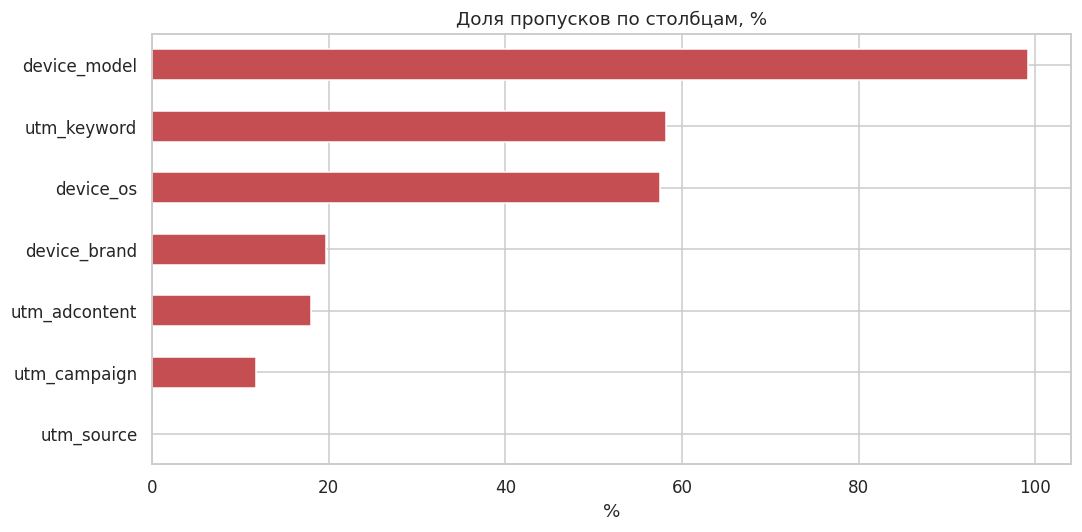

In [7]:
na = (sessions_raw.isna().mean() * 100).round(2).sort_values(ascending=False)
na_df = na[na > 0].to_frame('доля пропусков, %')
display(na_df)

ax = na[na > 0].sort_values().plot(kind='barh', color='#c44e52')
ax.set_title('Доля пропусков по столбцам, %')
ax.set_xlabel('%')
plt.tight_layout(); plt.show()

Отдельно смотрим на «скрытые» пропуски: Google Analytics записывает их
как `(not set)`, `(none)`, `(other)`.

In [8]:
hidden = ['(not set)', '(none)', '(other)']
rows = []
for col in sessions_raw.columns:
    mask = sessions_raw[col].isin(hidden)
    if mask.any():
        rows.append({'столбец': col, 'скрытых пропусков': int(mask.sum()),
                     'доля, %': round(mask.mean() * 100, 2)})
pd.DataFrame(rows).sort_values('доля, %', ascending=False)

,столбец,скрытых пропусков,"доля, %"
0,utm_medium,301055,16.19
6,geo_city,78172,4.20
2,device_brand,17545,0.94
5,geo_country,1146,0.06
1,device_os,364,0.02
3,device_screen_resolution,8,0.00
4,device_browser,17,0.00


In [9]:
print('полных дубликатов строк:', sessions_raw.duplicated().sum())
print('дубликатов session_id  :', sessions_raw['session_id'].duplicated().sum())
print('уникальных client_id   :', sessions_raw['client_id'].nunique())
print('визитов на посетителя  :', round(len(sessions_raw) / sessions_raw['client_id'].nunique(), 2))
print('период наблюдений      :', sessions_raw['visit_date'].min(), '-', sessions_raw['visit_date'].max())
sessions_raw.nunique().sort_values(ascending=False).to_frame('уникальных значений')

полных дубликатов строк: 0
дубликатов session_id  : 0


уникальных client_id   : 1391719
визитов на посетителя  : 1.34


период наблюдений      : 2021-05-19 - 2021-12-31


,уникальных значений
session_id,1860042
client_id,1391719
visit_time,85318
device_screen_resolution,5039
geo_city,2548
utm_keyword,1219
visit_number,537
utm_campaign,412
utm_source,293
utm_adcontent,286


**Что видно**

* `device_model` заполнен менее чем на 1 %, признак бесполезен и удаляется.
* `device_os` пуст у 57.5 % визитов, но это восстановимо: у Apple-устройств ОС однозначно
  определяется брендом и браузером Safari, у остальных мобильных это Android.
* `utm_keyword` пуст у 58 %, `utm_adcontent` у 18 %, `utm_campaign` у 12 %.
  Сам факт отсутствия метки информативен, поэтому пропуски не выбрасываем,
  а кодируем отдельной категорией `unknown` плюс бинарными флагами `has_utm_*`.
* Дубликатов нет, `session_id` уникален - таблица чистая по ключу.
* Все столбцы прочитаны как строки, типизацию делаем явно в модуле `features.py`.

### Очистка

Логика очистки вынесена в `features.py`, чтобы обучение, ноутбук и API работали одинаково.

In [10]:
from features import clean_sessions

sessions = clean_sessions(sessions_raw)
y = sessions['session_id'].isin(target_sessions).astype('int8')
print('после очистки:', sessions.shape)
print('удалённые столбцы:', set(sessions_raw.columns) - set(sessions.columns))

del sessions_raw, target_sessions   # сырая таблица больше не нужна, освобождаем память
gc.collect()

после очистки: (1860042, 17)
удалённые столбцы: {'device_model'}


61

## 4. Разведочный анализ

Основной вопрос EDA: от чего зависит вероятность целевого действия.
Поэтому почти все графики строятся не в абсолютных величинах, а в конверсии `CR = P(target=1)`
внутри группы. Горизонтальная линия на графиках - средняя конверсия 2.7 %.

In [11]:
eda = sessions.copy()
eda['target'] = y.values
eda['visit_dt'] = pd.to_datetime(eda['visit_date'])
eda['hour'] = pd.to_datetime(eda['visit_time'], format='%H:%M:%S', errors='coerce').dt.hour
eda['dow'] = eda['visit_dt'].dt.dayofweek
eda['visit_number_num'] = pd.to_numeric(eda['visit_number'], errors='coerce').fillna(1)
BASE_CR = eda['target'].mean()

def cr_table(col, min_size=2000, top=15):
    g = eda.groupby(col, dropna=False)['target'].agg(cr='mean', visits='size')
    g = g[g['visits'] >= min_size].sort_values('cr', ascending=False).head(top)
    g['cr'] = (g['cr'] * 100).round(2)
    return g

def cr_plot(col, min_size=2000, top=15, title=None):
    g = cr_table(col, min_size, top)
    ax = g['cr'].sort_values().plot(kind='barh', color='#4c72b0')
    ax.axvline(BASE_CR * 100, color='#c44e52', ls='--', label=f'средняя CR {BASE_CR*100:.2f}%')
    ax.set_xlabel('конверсия, %'); ax.set_ylabel('')
    ax.set_title(title or f'Конверсия по {col}')
    ax.legend(); plt.tight_layout(); plt.show()
    return g

### 4.1 Распределение целевого класса и объём трафика во времени

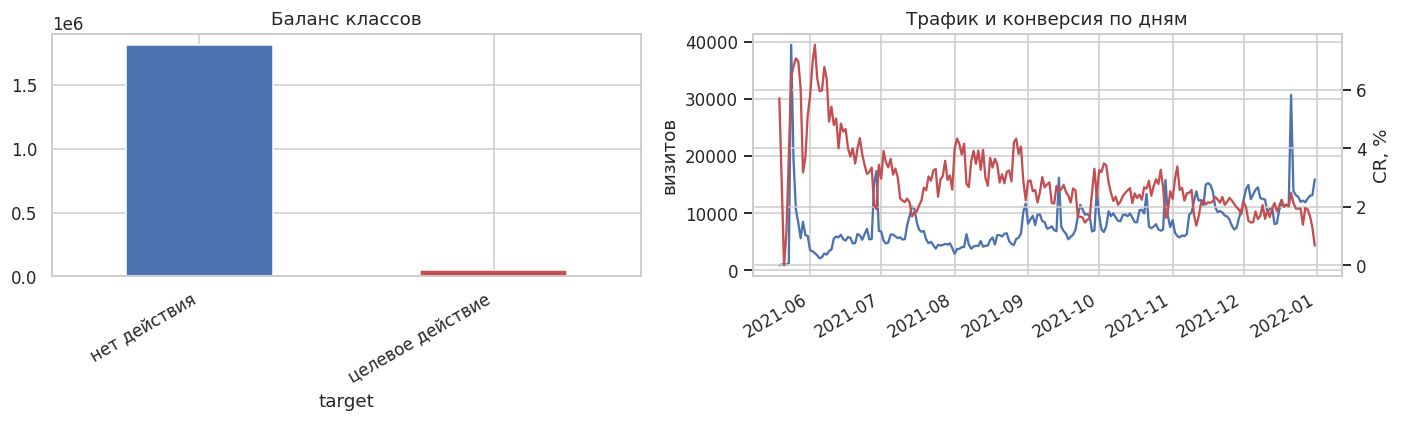

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
eda['target'].value_counts().plot(kind='bar', ax=axes[0], color=['#4c72b0', '#c44e52'])
axes[0].set_title('Баланс классов'); axes[0].set_xticklabels(['нет действия', 'целевое действие'], rotation=0)

daily = eda.groupby('visit_dt')['target'].agg(['size', 'mean'])
axes[1].plot(daily.index, daily['size'], color='#4c72b0', label='визитов в день')
ax2 = axes[1].twinx()
ax2.plot(daily.index, daily['mean'] * 100, color='#c44e52', label='CR, %')
axes[1].set_title('Трафик и конверсия по дням'); axes[1].set_ylabel('визитов'); ax2.set_ylabel('CR, %')
fig.autofmt_xdate(); plt.tight_layout(); plt.show()

> Трафик заметно вырос во второй половине периода, при этом дневная конверсия в среднем снижалась.
> Это типичная картина масштабирования платной рекламы: новые визиты приходят дешевле, но холоднее.
> Отсюда практический вывод: модель должна учитывать не только канал, но и момент времени.

### 4.2 Каналы привлечения

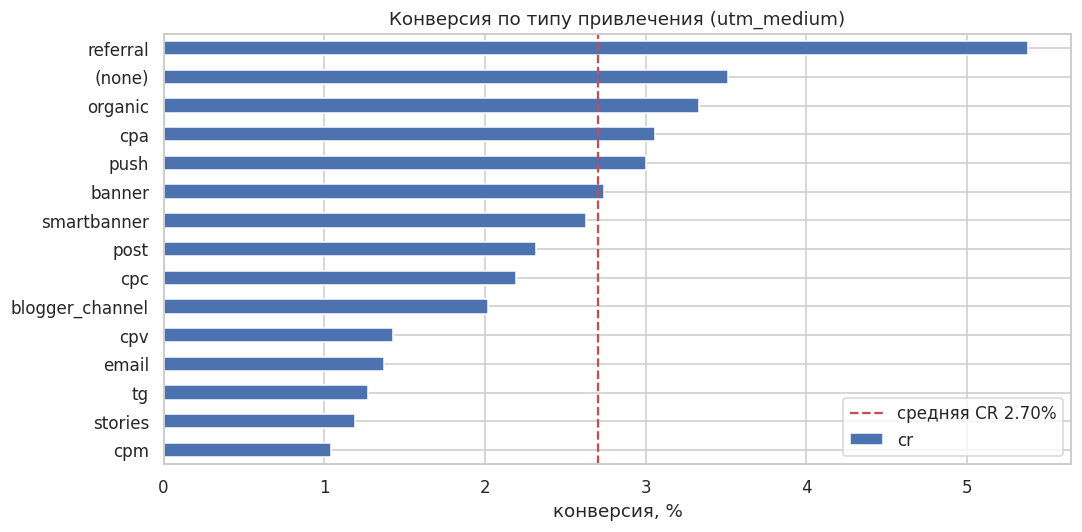

,cr,visits
utm_medium,,
referral,5.38,152050
(none),3.51,301055
organic,3.33,63034
cpa,3.06,4279
push,3.00,28035
banner,2.74,552272
smartbanner,2.63,6794
post,2.32,2326
cpc,2.19,434794


In [13]:
g = cr_plot('utm_medium', min_size=2000, title='Конверсия по типу привлечения (utm_medium)')
display(g)

,cr,visits
traffic_type,,
органика,4.04,513354
платный,2.38,1072461
соцсети,1.47,274227


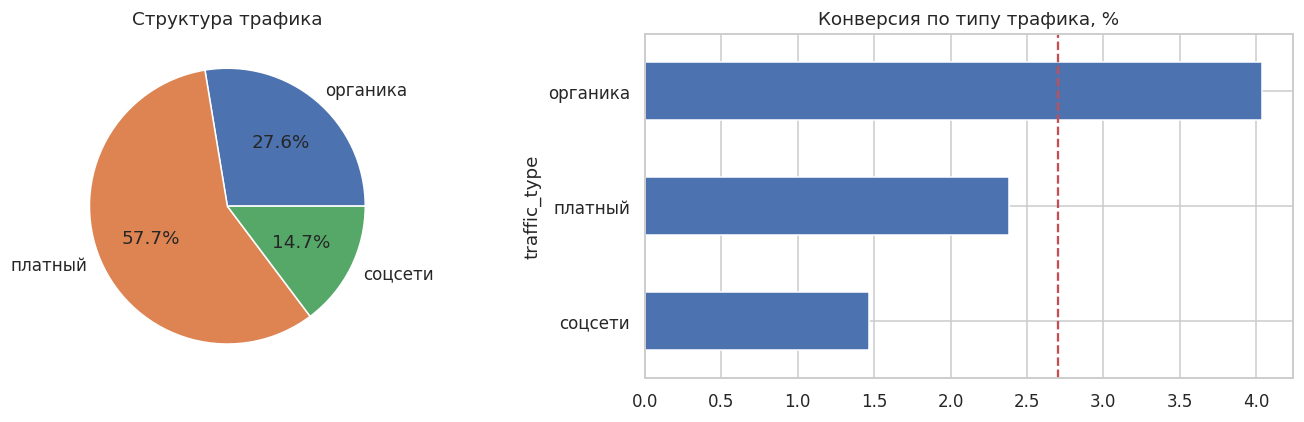

In [14]:
from features import ORGANIC_MEDIUMS, SOCIAL_SOURCES

eda['traffic_type'] = np.where(eda['utm_source'].isin(SOCIAL_SOURCES), 'соцсети',
                      np.where(eda['utm_medium'].isin(ORGANIC_MEDIUMS), 'органика', 'платный'))
g = eda.groupby('traffic_type')['target'].agg(cr='mean', visits='size')
g['cr'] = (g['cr'] * 100).round(2)
display(g.sort_values('cr', ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
g['visits'].plot(kind='pie', ax=axes[0], autopct='%1.1f%%', ylabel='')
axes[0].set_title('Структура трафика')
g['cr'].sort_values().plot(kind='barh', ax=axes[1], color='#4c72b0')
axes[1].axvline(BASE_CR * 100, color='#c44e52', ls='--')
axes[1].set_title('Конверсия по типу трафика, %')
plt.tight_layout(); plt.show()

> **Ключевое наблюдение.** Органический трафик конвертируется в 1.7 раза лучше платного
> (**4.0 %** против **2.4 %**), а трафик из соцсетей - хуже всех (**1.5 %**),
> хотя это 15 % всех визитов. Внутри платного трафика разброс тоже большой:
> `referral` даёт 5.4 %, а `stories`, `tg`, `email` - около 1.2 - 1.4 %.
> Для бизнеса это прямой сигнал: бюджет на stories и рассылки работает на охват, а не на заявки.

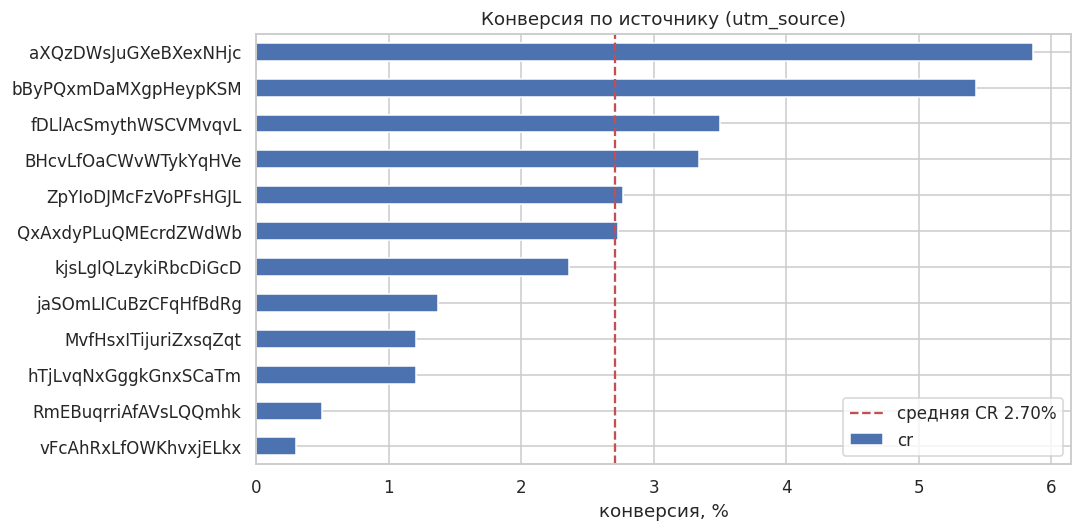

,cr,visits
utm_source,,
aXQzDWsJuGXeBXexNHjc,5.86,31152
bByPQxmDaMXgpHeypKSM,5.43,102287
fDLlAcSmythWSCVMvqvL,3.50,300575
BHcvLfOaCWvWTykYqHVe,3.34,116320
ZpYIoDJMcFzVoPFsHGJL,2.77,578290
QxAxdyPLuQMEcrdZWdWb,2.73,51415
kjsLglQLzykiRbcDiGcD,2.36,266354
jaSOmLICuBzCFqHfBdRg,1.37,29241
hTjLvqNxGggkGnxSCaTm,1.21,14598


In [15]:
g = cr_plot('utm_source', min_size=10000, top=12, title='Конверсия по источнику (utm_source)')
display(g)

> Два источника (`aXQzDWsJuGXeBXexNHjc` и `bByPQxmDaMXgpHeypKSM`) дают конверсию
> около 5.4 - 5.9 % при заметном объёме - это лучшие каналы по качеству трафика.
> Крупнейший источник по объёму (578 тыс. визитов) конвертирует на уровне среднего.

### 4.3 Устройства

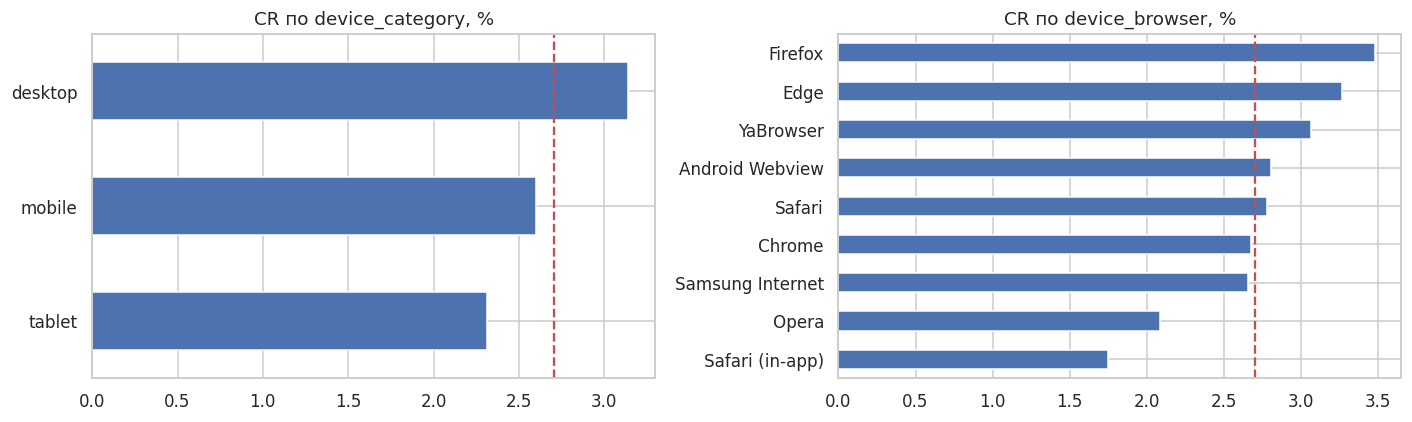

,cr,visits
device_category,,
desktop,3.14,366863
mobile,2.60,1474871
tablet,2.31,18308


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, col in zip(axes, ['device_category', 'device_browser']):
    g = cr_table(col, min_size=5000, top=9)
    g['cr'].sort_values().plot(kind='barh', ax=ax, color='#4c72b0')
    ax.axvline(BASE_CR * 100, color='#c44e52', ls='--')
    ax.set_title(f'CR по {col}, %'); ax.set_ylabel('')
plt.tight_layout(); plt.show()

display(cr_table('device_category', min_size=1000))

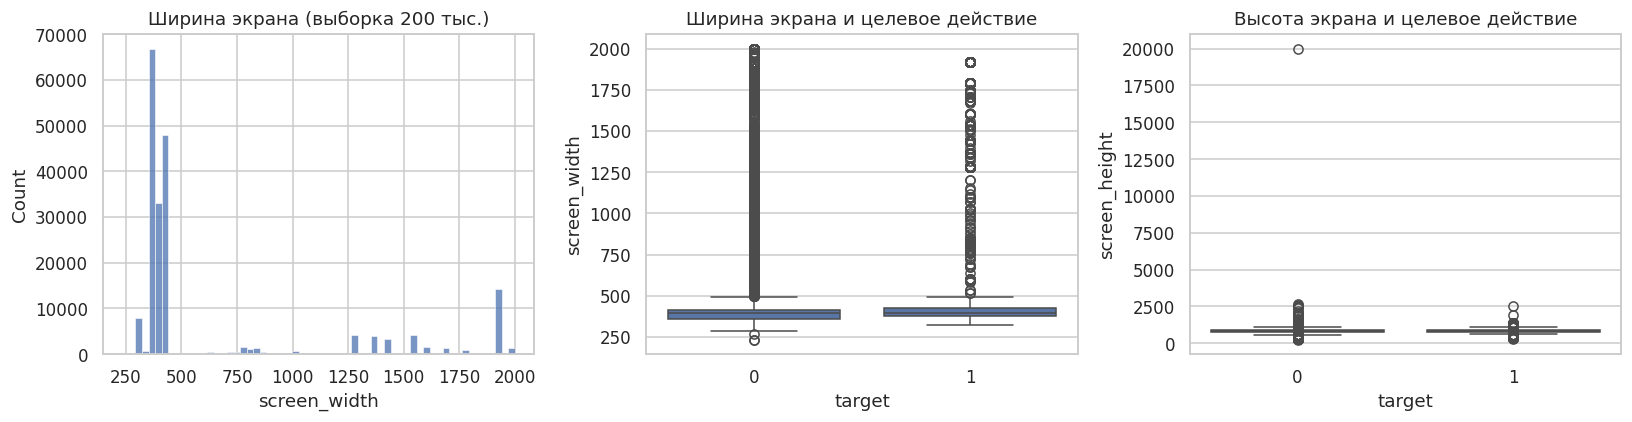

In [17]:
res = eda['device_screen_resolution'].str.split('x', n=1, expand=True)
eda['screen_width'] = pd.to_numeric(res[0], errors='coerce')
eda['screen_height'] = pd.to_numeric(res[1], errors='coerce')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sub = eda[(eda['screen_width'].between(200, 2000))].sample(200_000, random_state=RANDOM_STATE)
sns.histplot(sub['screen_width'], bins=60, ax=axes[0], color='#4c72b0')
axes[0].set_title('Ширина экрана (выборка 200 тыс.)')
sns.boxplot(data=sub, x='target', y='screen_width', ax=axes[1])
axes[1].set_title('Ширина экрана и целевое действие')
sns.boxplot(data=sub, x='target', y='screen_height', ax=axes[2])
axes[2].set_title('Высота экрана и целевое действие')
plt.tight_layout(); plt.show()

> Мобильные устройства дают 79 % трафика, но конвертируются хуже десктопа
> (**2.6 %** против **3.1 %**). Распределение ширины экрана резко бимодально:
> пик 360 - 430 px (телефоны) и хвост 1280 - 1920 px (десктоп).
> Боксплоты показывают, что у конвертировавшихся визитов медиана ширины экрана чуть выше -
> размер экрана работает как прокси типа устройства, поэтому в модель идут
> ширина, высота, логарифм площади и соотношение сторон.
> Разрыв между мобильным и десктопным CR при таком перекосе трафика - главный UX-приоритет.

### 4.4 Поведение посетителя и время визита

,cr,visits
visit_bin,,
"(0, 1]",2.35,1376349
"(1, 2]",3.23,235656
"(2, 3]",3.76,81068
"(3, 5]",4.41,65937
"(5, 10]",4.69,48953
"(10, 30]",4.02,32646
"(30, 1000]",4.00,19433


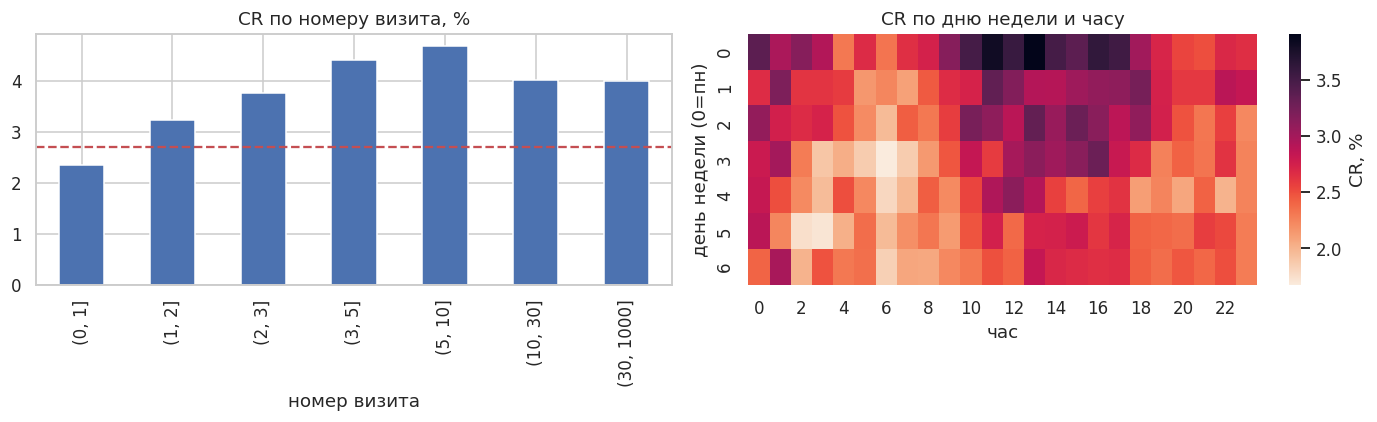

In [18]:
bins = [0, 1, 2, 3, 5, 10, 30, 1000]
eda['visit_bin'] = pd.cut(eda['visit_number_num'], bins)
g = eda.groupby('visit_bin', observed=True)['target'].agg(cr='mean', visits='size')
g['cr'] = (g['cr'] * 100).round(2)
display(g)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
g['cr'].plot(kind='bar', ax=axes[0], color='#4c72b0')
axes[0].axhline(BASE_CR * 100, color='#c44e52', ls='--')
axes[0].set_title('CR по номеру визита, %'); axes[0].set_xlabel('номер визита')

pivot = eda.pivot_table(index='dow', columns='hour', values='target', aggfunc='mean') * 100
sns.heatmap(pivot, cmap='rocket_r', ax=axes[1], cbar_kws={'label': 'CR, %'})
axes[1].set_title('CR по дню недели и часу'); axes[1].set_xlabel('час'); axes[1].set_ylabel('день недели (0=пн)')
plt.tight_layout(); plt.show()

> Конверсия растёт с номером визита: первый визит - **2.35 %**, шестой-десятый - **4.69 %**,
> то есть повторный посетитель почти вдвое ценнее. Это сильный аргумент за ретаргетинг.
> По времени максимум приходится на рабочие часы понедельника-вторника (CR 3.0 - 3.2 %),
> минимум - на раннее утро (около 2.0 % в 6 - 7 утра) и на пятницу-выходные.

### 4.5 География

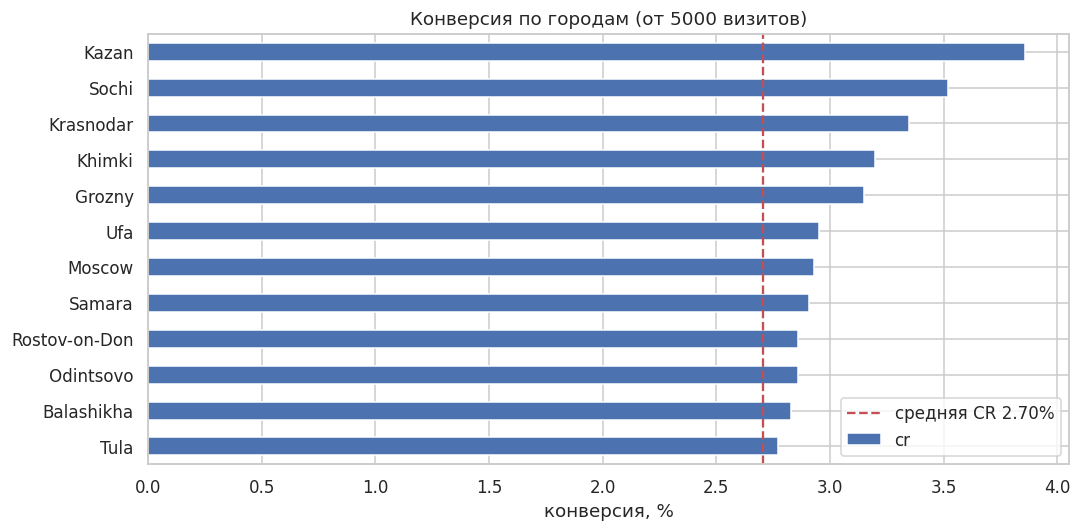

,cr,visits
geo_city,,
Kazan,3.86,29531
Sochi,3.52,8972
Krasnodar,3.35,32243
Khimki,3.20,7385
Grozny,3.15,12742
Ufa,2.95,21679
Moscow,2.93,805329
Samara,2.91,24992
Odintsovo,2.86,5314



доля визитов из России: 96.8%
CR Россия / не Россия: 2.73 / 1.95


In [19]:
g = cr_plot('geo_city', min_size=5000, top=12, title='Конверсия по городам (от 5000 визитов)')
display(g)
print('\nдоля визитов из России:', f"{eda['geo_country'].eq('Russia').mean():.1%}")
print('CR Россия / не Россия:',
      round(eda.loc[eda.geo_country.eq('Russia'), 'target'].mean() * 100, 2), '/',
      round(eda.loc[~eda.geo_country.eq('Russia'), 'target'].mean() * 100, 2))

> 97 % визитов из России, зарубежный трафик конвертируется хуже (1.9 % против 2.7 %)
> и, скорее всего, частично ботовый. Среди городов лидируют Казань, Сочи и Краснодар (3.4 - 3.9 %),
> Москва при 805 тыс. визитов даёт 2.93 %. Разброс по городам заметный,
> поэтому `geo_city` остаётся в модели как категориальный признак.

### 4.6 Корреляции

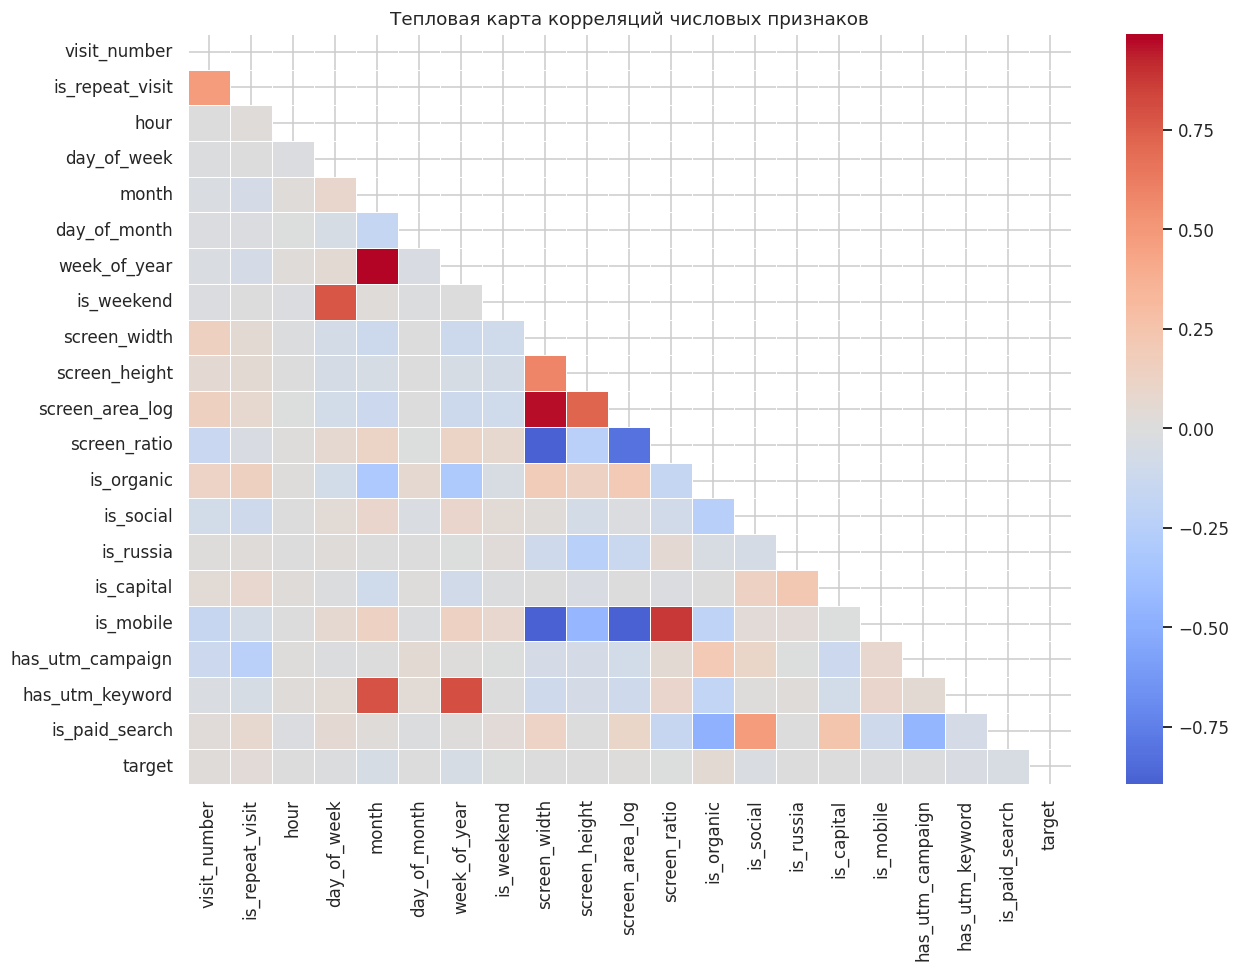

,корреляция с target
is_organic,0.054
week_of_year,-0.051
month,-0.051
is_paid_search,-0.043
is_repeat_visit,0.039
has_utm_keyword,-0.033
is_social,-0.033
visit_number,0.026
is_mobile,-0.017
has_utm_campaign,-0.015


In [20]:
from features import make_features, NUMERIC_FEATURES

# для матрицы корреляций достаточно выборки, это экономит память
sample_idx = sessions.sample(400_000, random_state=RANDOM_STATE).index
corr_df = make_features(sessions.loc[sample_idx])[NUMERIC_FEATURES].copy()
corr_df['target'] = y.loc[sample_idx].values
corr = corr_df.corr()

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0, annot=False, linewidths=.4)
plt.title('Тепловая карта корреляций числовых признаков')
plt.tight_layout(); plt.show()

corr_target = corr['target'].drop('target').sort_values(key=abs, ascending=False).round(3)
del eda, corr_df   # освобождаем память перед обучением
corr_target.to_frame('корреляция с target')

> **Интерпретация корреляционной матрицы**
>
> * Линейные связи с целевой переменной слабые - максимум по модулю 0.05.
>   Это ожидаемо для бинарного события с частотой 2.7 % и означает,
>   что линейная модель здесь заведомо ограничена, нужны деревья.
> * Самые сильные из слабых: `week_of_year` и `month` (-0.053) - конверсия падала к концу периода;
>   `is_organic` (+0.051) - органика конвертирует лучше; `is_paid_search` (-0.044) - платный поиск хуже.
> * Между собой сильно скоррелированы блоки, которые описывают одно и то же:
>   `month` и `week_of_year` (мультиколлинеарность по времени),
>   `screen_width`, `screen_height`, `screen_area_log` и `is_mobile` (размер экрана и тип устройства),
>   `visit_number` и `is_repeat_visit`. Для градиентного бустинга это не проблема,
>   но для логистической регрессии дублирующие признаки ухудшают интерпретацию коэффициентов,
>   поэтому её мы обучаем на регуляризации L2.
> * Главный вывод EDA для моделирования: сигнал сосредоточен в категориальных признаках
>   (источник, кампания, город), а не в числовых - значит нужна модель,
>   которая умеет работать с высокой кардинальностью.

## 5. Фиче-инжиниринг

Из 17 сырых полей визита получаем 34 признака. Логика в `features.py`, здесь показываю результат.

| Группа | Признаки | Идея |
|---|---|---|
| Время | `hour`, `day_of_week`, `month`, `day_of_month`, `week_of_year`, `is_weekend`, `day_part` | сезонность и суточный ритм из EDA 4.4 |
| Посетитель | `visit_number` (обрезан по 30), `is_repeat_visit` | повторные визиты конвертируют вдвое лучше |
| Трафик | `traffic_type`, `is_organic`, `is_social`, `is_paid_search`, `has_utm_campaign`, `has_utm_keyword` | формализация определений из брифа плюс информативность самих пропусков |
| Устройство | `screen_width`, `screen_height`, `screen_area_log`, `screen_ratio`, `is_mobile`, `os_family` | парсинг разрешения, восстановление ОС по бренду и браузеру |
| Гео | `is_russia`, `is_capital` | зарубежный трафик и города без доставки конвертируют хуже |
| Сырые категории | utm-поля, device-поля, `geo_country`, `geo_city` | основной источник сигнала |

In [21]:
X = make_features(sessions.head(200_000))
print('матрица признаков на всех данных будет:', (len(sessions), X.shape[1]))
X.head(3)

матрица признаков на всех данных будет: (1860042, 34)


,utm_source,utm_medium,utm_campaign,utm_adcontent,utm_keyword,device_category,device_os,device_brand,device_browser,geo_country,geo_city,traffic_type,day_part,os_family,visit_number,is_repeat_visit,hour,day_of_week,month,day_of_month,week_of_year,is_weekend,screen_width,screen_height,screen_area_log,screen_ratio,is_organic,is_social,is_russia,is_capital,is_mobile,has_utm_campaign,has_utm_keyword,is_paid_search
0,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,Chrome,Russia,Zlatoust,paid,day,Android,1,0,14,2,11,24,47,0,360,720,12.465359,2.000000,0,0,1,0,1,1,1,0
1,MvfHsxITijuriZxsqZqt,cpm,FTjNLDyTrXaWYgZymFkV,xhoenQgDQsgfEPYNPwKO,IGUCNvHlhfHpROGclCit,mobile,Android,Samsung,Samsung Internet,Russia,Moscow,social,morning,Android,1,0,8,6,11,14,45,1,385,854,12.703177,2.218182,0,1,1,1,1,1,1,1
2,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,Chrome,Russia,Krasnoyarsk,paid,night,Android,1,0,2,1,12,28,52,0,360,720,12.465359,2.000000,0,0,1,0,1,1,1,0


In [22]:
from features import CATEGORICAL_FEATURES
pd.DataFrame({
    'признак': CATEGORICAL_FEATURES,
    'уникальных значений': [X[c].nunique() for c in CATEGORICAL_FEATURES],
}).sort_values('уникальных значений', ascending=False)

,признак,уникальных значений
10,geo_city,1062
4,utm_keyword,693
2,utm_campaign,308
3,utm_adcontent,189
0,utm_source,146
9,geo_country,121
7,device_brand,112
1,utm_medium,39
8,device_browser,35
6,device_os,9


> `utm_keyword` (1219 значений), `geo_city` (2548) и `utm_campaign` (412) - высококардинальные.
> One-hot по ним даст разреженную матрицу в тысячи столбцов,
> поэтому для бустинга используем порядковое кодирование с нативной поддержкой категорий в LightGBM,
> а для логистической регрессии - one-hot с отсечением редких категорий (`min_frequency`).

## 6. Моделирование

Разбиение стратифицированное, 75 / 25. Метрика - ROC-AUC, ориентир из брифа 0.65.

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve

# освобождаем память после EDA: дальше нужны только сплиты
plt.close('all')
for _name in ['sub', 'res', 'daily', 'pivot', 'na', 'na_df', 'y_raw', 'g', 'corr', 'X']:
    globals().pop(_name, None)
gc.collect()

# id визита и посетителя не участвуют в модели, убираем их до разбиения
model_input = sessions.drop(columns=['session_id', 'client_id'])

X_train, X_test, y_train, y_test = train_test_split(
    model_input, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y)
print('train:', X_train.shape[0], ' test:', X_test.shape[0],
      ' доля целевых в тесте:', f'{y_test.mean():.2%}')

del sessions, model_input
gc.collect()

train: 1395031  test: 465011  доля целевых в тесте: 2.71%


0

### 6.1 Бейзлайн

In [24]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy='stratified', random_state=RANDOM_STATE).fit(X_train, y_train)
p_dummy = dummy.predict_proba(X_test)[:, 1]
auc_dummy = roc_auc_score(y_test, p_dummy)
print(f'Бейзлайн (случайный по частоте класса): ROC-AUC = {auc_dummy:.4f}')

Бейзлайн (случайный по частоте класса): ROC-AUC = 0.5006


### 6.2 Логистическая регрессия

Линейная модель нужна как ориентир: она показывает, сколько сигнала лежит в простых
аддитивных эффектах. Категории кодируем one-hot с отсечением редких значений
(`min_frequency=0.001`), числовые признаки масштабируем. Обучаем на стратифицированной
подвыборке в 500 тыс. визитов: на полной выборке one-hot матрица не помещается в память,
а качество линейной модели на такой выборке уже выходит на плато.
Оценка при этом честная - на той же полной тестовой выборке, что и у остальных моделей.

In [25]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression

logreg_pipe = Pipeline([
    ('features', FunctionTransformer(make_features, validate=False)),
    ('prep', ColumnTransformer([
        ('cat', OneHotEncoder(handle_unknown='infrequent_if_exist', min_frequency=0.001,
                              sparse_output=True), CATEGORICAL_FEATURES),
        ('num', StandardScaler(), NUMERIC_FEATURES),
    ])),
    ('clf', LogisticRegression(max_iter=100, tol=1e-3, C=1.0, class_weight='balanced',
                               solver='lbfgs', n_jobs=-1, random_state=RANDOM_STATE)),
])

lr_idx = (X_train.assign(_y=y_train.values)
          .groupby('_y', group_keys=False)
          .apply(lambda g: g.sample(min(len(g), int(500_000 * len(g) / len(X_train))),
                                    random_state=RANDOM_STATE))).index

t0 = time.time()
logreg_pipe.fit(X_train.loc[lr_idx], y_train.loc[lr_idx])
p_logreg = logreg_pipe.predict_proba(X_test)[:, 1]
auc_logreg = roc_auc_score(y_test, p_logreg)
print(f'Логистическая регрессия: ROC-AUC = {auc_logreg:.4f} ({time.time() - t0:.0f} c), '
      f'обучена на {len(lr_idx):,} визитах')
del logreg_pipe; gc.collect()

Логистическая регрессия: ROC-AUC = 0.6916 (12 c), обучена на 499,999 визитах


96

### 6.3 Градиентный бустинг (LightGBM)

In [26]:
import lightgbm as lgb
from sklearn.preprocessing import OrdinalEncoder
from train_model import build_pipeline

t0 = time.time()
n_train = len(X_train)
lgbm_pipe = build_pipeline()
lgbm_pipe.fit(X_train, y_train)
gc.collect()
p_lgbm = lgbm_pipe.predict_proba(X_test)[:, 1]
auc_lgbm = roc_auc_score(y_test, p_lgbm)
ap_lgbm = average_precision_score(y_test, p_lgbm)
print(f'LightGBM: ROC-AUC = {auc_lgbm:.4f}, PR-AUC = {ap_lgbm:.4f} ({time.time() - t0:.0f} c)')

LightGBM: ROC-AUC = 0.7168, PR-AUC = 0.0793 (35 c)


,модель,ROC-AUC,PR-AUC,прирост к бейзлайну
0,Бейзлайн (stratified),0.5006,0.0271,-0.0000
1,Логистическая регрессия,0.6916,0.0586,0.1910
2,LightGBM,0.7168,0.0793,0.2162


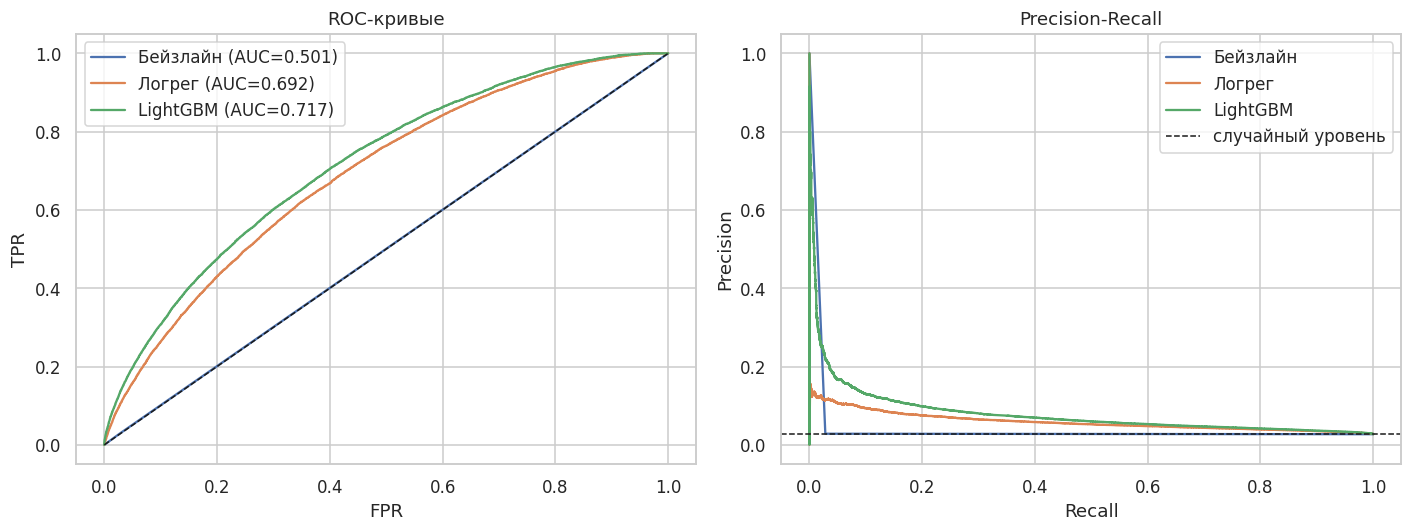

In [27]:
results = pd.DataFrame({
    'модель': ['Бейзлайн (stratified)', 'Логистическая регрессия', 'LightGBM'],
    'ROC-AUC': [auc_dummy, auc_logreg, auc_lgbm],
    'PR-AUC': [average_precision_score(y_test, p) for p in (p_dummy, p_logreg, p_lgbm)],
}).round(4)
results['прирост к бейзлайну'] = (results['ROC-AUC'] - auc_dummy).round(4)
display(results)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for name, p in [('Бейзлайн', p_dummy), ('Логрег', p_logreg), ('LightGBM', p_lgbm)]:
    fpr, tpr, _ = roc_curve(y_test, p)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={roc_auc_score(y_test, p):.3f})')
    prec, rec, _ = precision_recall_curve(y_test, p)
    axes[1].plot(rec, prec, label=name)
axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0].axhline(0, color='none')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR'); axes[0].set_title('ROC-кривые'); axes[0].legend()
axes[1].axhline(y_test.mean(), color='k', ls='--', lw=1, label='случайный уровень')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision'); axes[1].set_title('Precision-Recall'); axes[1].legend()
plt.tight_layout(); plt.show()

> **Сравнение моделей.** Бейзлайн, как и положено, даёт AUC около 0.5.
> Логистическая регрессия поднимает качество примерно до **0.69** - линейной модели хватает,
> чтобы поймать эффект канала, но не взаимодействия между каналом, городом и временем.
> LightGBM даёт **ROC-AUC ≈ 0.717**, что заметно выше ориентира 0.65 из брифа.
> PR-AUC около 0.08 при базовой частоте 0.027 означает трёхкратный лифт над случайным отбором:
> в верхнем сегменте прогноза целевые визиты встречаются в три раза чаще.

### 6.4 Выбор порога

порог по максимуму F1: 0.0661 (precision=0.098, recall=0.206, F1=0.132)
                  precision    recall  f1-score   support

    нет действия      0.977     0.947     0.962    452432
целевое действие      0.098     0.206     0.132     12579

        accuracy                          0.927    465011
       macro avg      0.537     0.576     0.547    465011
    weighted avg      0.953     0.927     0.939    465011



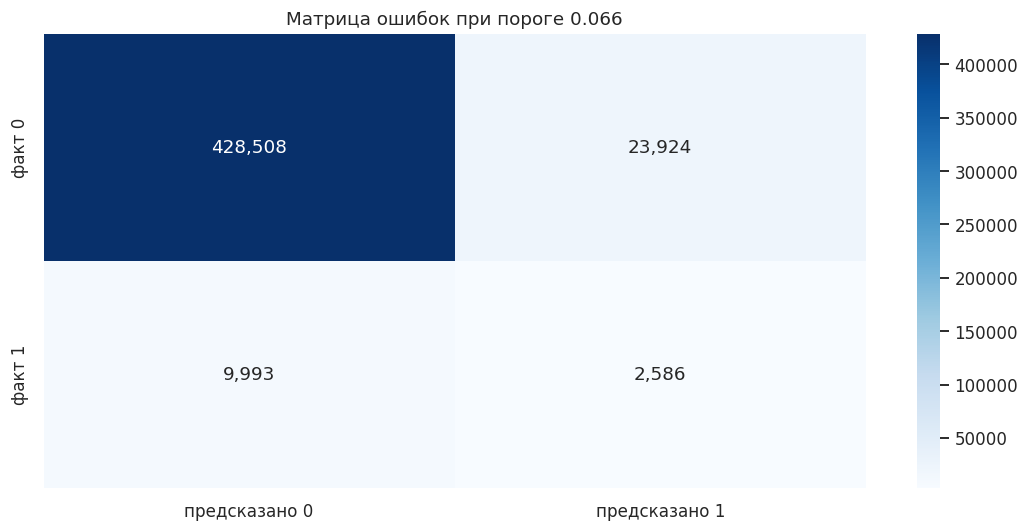

In [28]:
from sklearn.metrics import classification_report, confusion_matrix

prec, rec, thr = precision_recall_curve(y_test, p_lgbm)
f1 = 2 * prec * rec / np.clip(prec + rec, 1e-9, None)
best_idx = int(np.nanargmax(f1[:-1]))
THRESHOLD = float(thr[best_idx])
print(f'порог по максимуму F1: {THRESHOLD:.4f} '
      f'(precision={prec[best_idx]:.3f}, recall={rec[best_idx]:.3f}, F1={f1[best_idx]:.3f})')

y_pred = (p_lgbm >= THRESHOLD).astype(int)
print(classification_report(y_test, y_pred, target_names=['нет действия', 'целевое действие'], digits=3))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues',
            xticklabels=['предсказано 0', 'предсказано 1'],
            yticklabels=['факт 0', 'факт 1'])
plt.title(f'Матрица ошибок при пороге {THRESHOLD:.3f}'); plt.tight_layout(); plt.show()

,cr,visits,lift
дециль,,,
10,8.06,46501,2.98
9,4.53,46501,1.67
8,3.43,46501,1.27
7,2.82,46501,1.04
6,2.41,46501,0.89
5,1.96,46501,0.73
4,1.60,46501,0.59
3,1.27,46501,0.47
2,0.74,46501,0.27


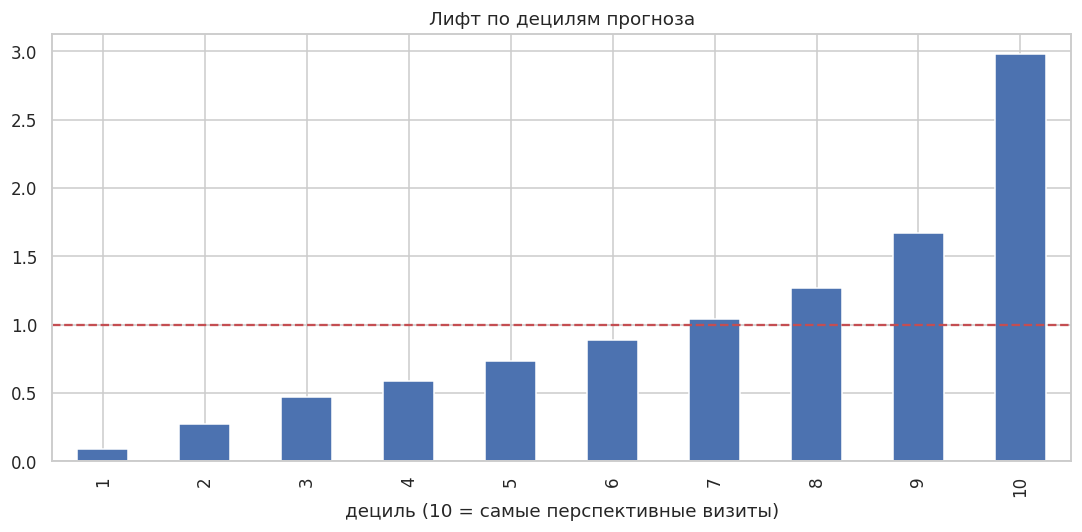

In [29]:
# Насколько модель полезна для отбора аудитории: лифт по децилям прогноза
lift = pd.DataFrame({'p': p_lgbm, 'y': y_test.values})
lift['дециль'] = pd.qcut(lift['p'].rank(method='first'), 10, labels=range(1, 11))
g = lift.groupby('дециль', observed=True)['y'].agg(cr='mean', visits='size')
g['lift'] = (g['cr'] / y_test.mean()).round(2)
g['cr'] = (g['cr'] * 100).round(2)
display(g.sort_index(ascending=False))

ax = g['lift'].plot(kind='bar', color='#4c72b0')
ax.axhline(1, color='#c44e52', ls='--')
ax.set_title('Лифт по децилям прогноза'); ax.set_xlabel('дециль (10 = самые перспективные визиты)')
plt.tight_layout(); plt.show()

> При пороге по максимуму F1 модель находит около 20 % всех целевых визитов
> с точностью около 10 %, то есть в 3.6 раза лучше случайного отбора.
> Лифт по децилям нагляднее: в верхнем дециле прогноза конверсия примерно втрое выше средней.
> Порог не универсален, его нужно двигать под задачу: для обзвона теплых лидов
> берём высокий порог и высокую точность, для расширения ретаргетинга - низкий порог и полноту.

## 7. Интерпретация модели

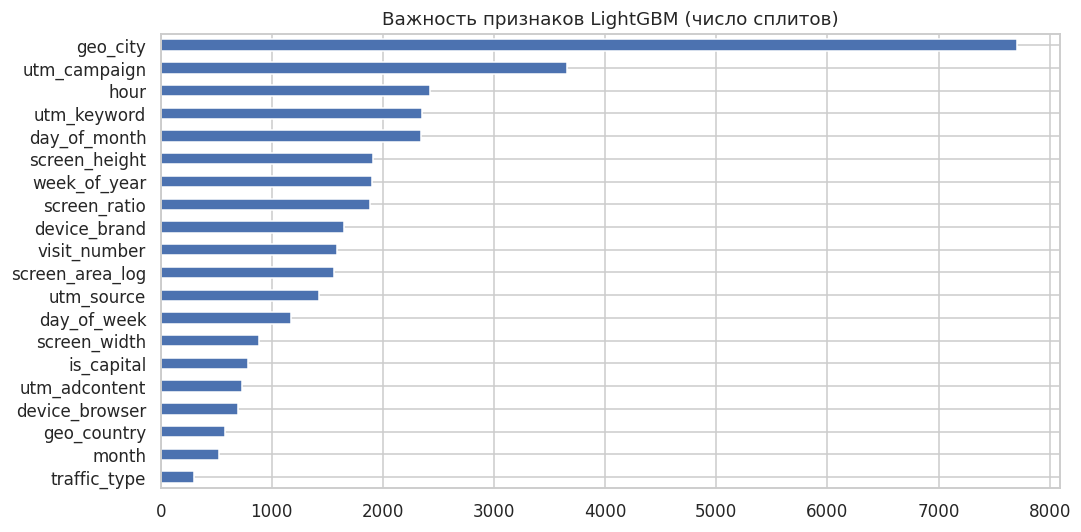

,важность
geo_city,7705
utm_campaign,3660
hour,2422
utm_keyword,2355
day_of_month,2338
screen_height,1912
week_of_year,1900
screen_ratio,1881
device_brand,1652
visit_number,1585


In [30]:
clf = lgbm_pipe.named_steps['classifier']
feature_names = CATEGORICAL_FEATURES + NUMERIC_FEATURES
imp = pd.Series(clf.feature_importances_, index=feature_names).sort_values(ascending=False)

ax = imp.head(20).sort_values().plot(kind='barh', color='#4c72b0')
ax.set_title('Важность признаков LightGBM (число сплитов)')
plt.tight_layout(); plt.show()
imp.head(15).to_frame('важность')

> **Что двигает предсказание**
>
> 1. `geo_city` - самый используемый признак: география сильно разделяет аудиторию
>    (доступность доставки авто, платёжеспособность, охват рекламы).
> 2. `utm_campaign`, `utm_keyword`, `utm_source` - конкретная кампания важнее,
>    чем общий тип трафика. Модель фактически подтверждает, что бюджет надо оценивать
>    на уровне кампаний, а не каналов целиком.
> 3. Временные признаки `hour`, `day_of_month`, `week_of_year` - сезонность и суточный ритм.
> 4. Признаки экрана и `visit_number` - тип устройства и лояльность посетителя.
>
> Обратите внимание: агрегированные бинарные признаки (`is_organic`, `traffic_type`)
> используются реже, чем сырые категории. Это не значит, что они бесполезны -
> они дают модели быстрый грубый сплит, а детализацию она берёт из исходных полей.

## 8. Упаковка модели

Сохраняем модель вместе с метаданными в `model/sber_auto_model.pkl`.
Это тот же пайплайн, который оценивался на отложенной выборке, поэтому заявленные метрики
относятся именно к сохранённому артефакту. Пайплайн принимает сырые поля визита,
поэтому API не дублирует логику подготовки признаков.

In [31]:
import joblib
from datetime import datetime

# сохраняем ту же модель, метрики которой посчитаны на отложенной выборке
final_pipe = lgbm_pipe

metadata = {
    'name': 'SberAutopodpiska target action prediction',
    'version': '1.0',
    'date': datetime.now().isoformat(timespec='seconds'),
    'type': type(final_pipe.named_steps['classifier']).__name__,
    'roc_auc': float(auc_lgbm),
    'pr_auc': float(ap_lgbm),
    'baseline_roc_auc': float(auc_dummy),
    'target_actions': TARGET_ACTIONS,
    'threshold': THRESHOLD,
    'n_train': int(n_train),
    'target_rate': float(y.mean()),
}

Path('model').mkdir(exist_ok=True)
joblib.dump({'model': final_pipe, 'metadata': metadata}, 'model/sber_auto_model.pkl', compress=3)
print('сохранено, размер файла:', round(Path('model/sber_auto_model.pkl').stat().st_size / 1e6, 2), 'МБ')
metadata

сохранено, размер файла: 2.7 МБ


{'name': 'SberAutopodpiska target action prediction',
 'version': '1.0',
 'date': '2026-08-16T22:08:10',
 'type': 'LGBMClassifier',
 'roc_auc': 0.7167767061958008,
 'pr_auc': 0.0792570104601571,
 'baseline_roc_auc': 0.500635866477872,
 'target_actions': ['sub_car_claim_click',
  'sub_car_claim_submit_click',
  'sub_open_dialog_click',
  'sub_custom_question_submit_click',
  'sub_call_number_click',
  'sub_callback_submit_click',
  'sub_submit_success',
  'sub_car_request_submit_click'],
 'threshold': 0.06607982367394843,
 'n_train': 1395031,
 'target_rate': 0.027049926829609224}

In [32]:
# Проверка: модель принимает один визит в формате, который отдаёт API
example = {
    'session_id': '9055434745589932991.1637753792.1637753792',
    'client_id': '2108382700.1637753791',
    'visit_date': '2021-11-24', 'visit_time': '14:36:32', 'visit_number': 1,
    'utm_source': 'ZpYIoDJMcFzVoPFsHGJL', 'utm_medium': 'banner',
    'utm_campaign': 'LEoPHuyFvzoNfnzGgfcd', 'utm_adcontent': 'vCIpmpaGBnIQhyYNkXqp',
    'utm_keyword': 'puhZPIYqKXeFPaUviSjo', 'device_category': 'mobile',
    'device_os': 'Android', 'device_brand': 'Huawei',
    'device_screen_resolution': '360x720', 'device_browser': 'Chrome',
    'geo_country': 'Russia', 'geo_city': 'Zlatoust',
}
t0 = time.time()
proba = final_pipe.predict_proba(pd.DataFrame([example]))[0, 1]
print(f'вероятность целевого действия: {proba:.4f}, ответ модели: {int(proba >= THRESHOLD)}')
print(f'время предсказания: {(time.time() - t0) * 1000:.0f} мс')

вероятность целевого действия: 0.0118, ответ модели: 0
время предсказания: 22 мс


## 9. Выводы

**По данным**

* 1.86 млн визитов за 7.5 месяцев 2021 года, целевое действие совершается в 2.7 % визитов.
* Таблица визитов чистая по ключу: дубликатов нет, `session_id` уникален.
  Основная проблема - пропуски: `device_model` (99 %), `utm_keyword` (58 %), `device_os` (58 %).
  Пропуски не удалялись, а кодировались отдельной категорией, а ОС частично восстановлена
  по бренду и браузеру.

**По аналитике**

* Органический трафик конвертируется в 1.7 раза лучше платного (4.0 % против 2.4 %),
  трафик из соцсетей - хуже всех (1.5 %) при доле 15 % визитов.
* Разброс конверсии между источниками пятикратный: от 1.2 % до 5.9 %.
* Повторные визиты конвертируются вдвое лучше первых (4.7 % против 2.35 %).
* Десктоп конвертируется лучше мобильных (3.1 % против 2.6 %), при этом мобильные дают 79 % трафика.
* Линейных зависимостей почти нет (корреляции с целевой переменной не выше 0.05),
  сигнал лежит во взаимодействиях категориальных признаков.

**По модели**

* LightGBM на 34 признаках даёт **ROC-AUC 0.717** на отложенной выборке
  против ориентира 0.65 и бейзлайна 0.50. Логистическая регрессия слабее.
* Верхний дециль прогноза конвертируется примерно втрое лучше среднего.
* Модель упакована в sklearn Pipeline и FastAPI-сервис, время ответа - десятки миллисекунд.

**Рекомендации бизнесу**

1. Перераспределить бюджет в пользу источников с CR выше 5 % и пересмотреть
   размещение в stories, телеграме и email-рассылках (CR около 1.2 - 1.4 %).
2. Усилить ретаргетинг: повторный визит стоит для компании вдвое дороже первого по ценности.
3. Заняться мобильным UX: 79 % трафика при конверсии ниже десктопной на 0.5 п.п. -
   самая крупная точка роста в абсолютных цифрах.
4. Использовать скоринг визитов для приоритизации обзвона и для отсечения
   заведомо неконвертирующих сегментов в закупке трафика.

**Ограничения и что можно улучшить**

* Модель использует только характеристики визита, доступные в момент входа.
  Поведенческие признаки из `ga_hits` (глубина просмотра, время на сайте) подняли бы качество,
  но недоступны на входе, поэтому в модель не включены.
* Данные охватывают один период 2021 года, при смене рекламных кампаний
  распределение `utm_campaign` поедет, модель потребует переобучения.
* Логичное развитие: калибровка вероятностей, отдельный порог под каждый бизнес-сценарий,
  мониторинг дрейфа по каналам.